In [32]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
# assumes working directory is project root (default in VS Code)
try:
    df = pd.read_parquet("data/processed/stress_score.parquet")
    DOCS_PATH = Path("docs")
except FileNotFoundError:
    df = pd.read_parquet("../data/processed/stress_score.parquet")
    DOCS_PATH = Path("../docs")

df = df.dropna()
df.index = pd.to_datetime(df.index)

In [34]:
STRESS_PERIODS = [
    ("2011-07-01", "2011-10-01", "EU debt crisis"),
    ("2015-08-01", "2016-02-01", "China slowdown"),
    ("2018-10-01", "2018-12-31", "Q4 selloff"),
    ("2020-02-01", "2020-04-01", "COVID crash"),
    ("2022-01-01", "2022-10-01", "Rate hike cycle"),
    ("2025-01-20", "2025-04-01", "Tariff shock"),
]

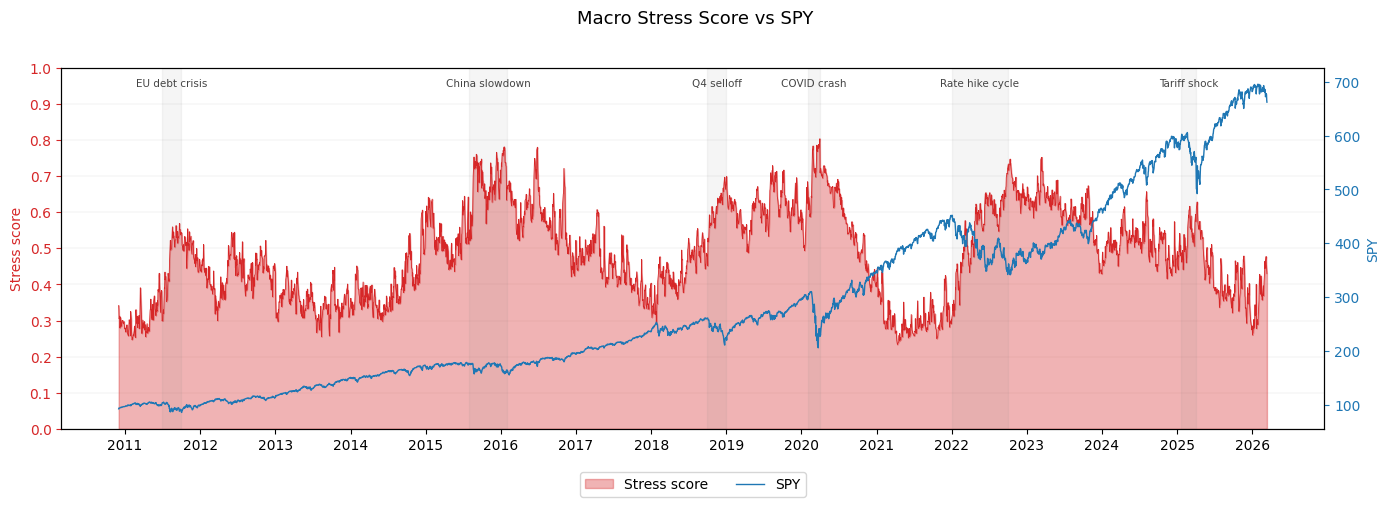

In [35]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    df.index, df["STRESS_SCORE"], alpha=0.35, color="#d62728", label="Stress score"
)
ax1.plot(df.index, df["STRESS_SCORE"], color="#d62728", linewidth=0.6)
ax2.plot(df.index, df["SPY"], color="#1f77b4", linewidth=1.0, label="SPY")

for start, end, label in STRESS_PERIODS:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax1.text(
        mid,
        0.97,
        label,
        ha="center",
        va="top",
        fontsize=7.5,
        color="#444444",
        transform=ax1.get_xaxis_transform(),
    )

ax1.set_ylabel("Stress score", color="#d62728")
ax2.set_ylabel("SPY", color="#1f77b4")
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax1.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax1.set_axisbelow(True)
ax2.yaxis.grid(False)
ax1.tick_params(axis="y", colors="#d62728")
ax2.tick_params(axis="y", colors="#1f77b4")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
)


fig.suptitle("Macro Stress Score vs SPY", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(DOCS_PATH / "stress_vs_spy.png", bbox_inches="tight", dpi=150)
plt.show()

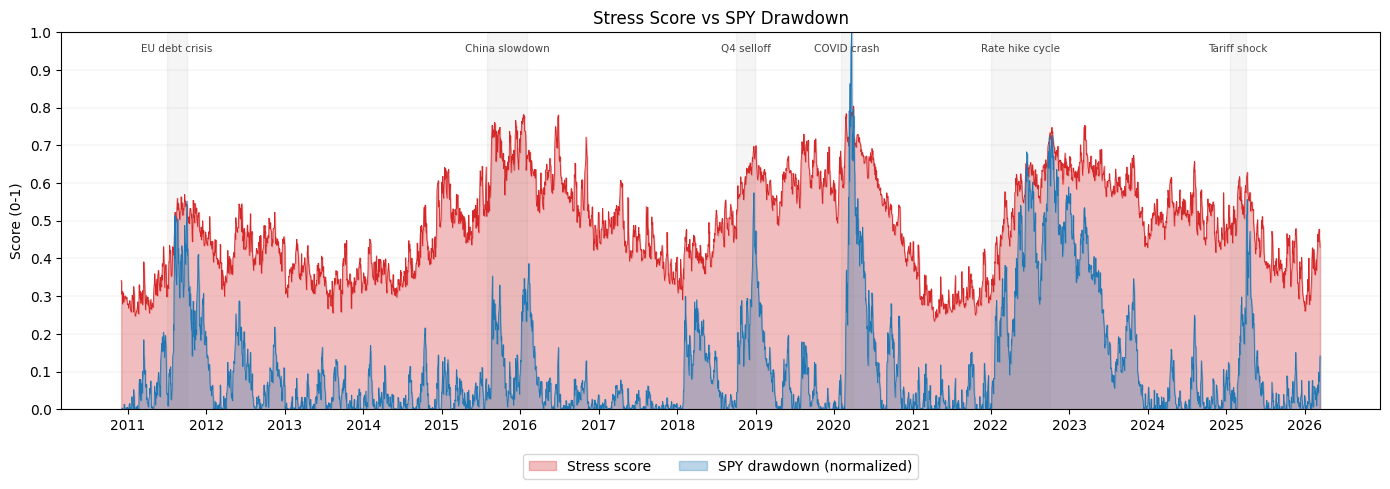

In [36]:
# Stress score vs SPY drawdown (normalized to 0-1, where 1 = worst drawdown)
spy_dd = df["SPY"] / df["SPY"].cummax() - 1
spy_dd_norm = (spy_dd - spy_dd.min()) / (spy_dd.max() - spy_dd.min())
spy_dd_norm = 1 - spy_dd_norm  # invert so crashes spike up

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    df.index, df["STRESS_SCORE"], alpha=0.3, color="#d62728", label="Stress score"
)
ax.fill_between(
    df.index, spy_dd_norm, alpha=0.3, color="#1f77b4", label="SPY drawdown (normalized)"
)
ax.plot(df.index, df["STRESS_SCORE"], color="#d62728", linewidth=0.6)
ax.plot(df.index, spy_dd_norm, color="#1f77b4", linewidth=0.6)

for start, end, label in STRESS_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(
        mid,
        0.97,
        label,
        ha="center",
        va="top",
        fontsize=7.5,
        color="#444444",
        transform=ax.get_xaxis_transform(),
    )

ax.set_ylim(0, 1)
ax.set_ylabel("Score (0-1)")
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax.set_axisbelow(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.legend(loc="lower left", fontsize=9)
# ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')  # right of plot
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.set_title("Stress Score vs SPY Drawdown")

plt.tight_layout()
fig.savefig(DOCS_PATH / "stress_vs_drawdown.png", bbox_inches="tight", dpi=150)
plt.show()

In [37]:
# Recent readings
df[["STRESS_SCORE", "SPY"]].tail(10).sort_index(ascending=False).round(3)

,STRESS_SCORE,SPY
Date,,
2026-03-13,0.430,662.29
2026-03-12,0.440,666.06
2026-03-11,0.450,676.33
2026-03-10,0.455,677.18
2026-03-09,0.478,678.27
2026-03-06,0.462,672.38
2026-03-05,0.458,681.31
2026-03-04,0.444,685.13
2026-03-03,0.464,680.33


In [ ]:
# Indicator breakdown: most recent observation
score_cols = [c for c in df.columns if c not in ("STRESS_SCORE", "SPY")]
latest = df[score_cols].iloc[-1].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [
    "#d62728" if v >= 0.6 else "#ff7f0e" if v >= 0.4 else "#2ca02c" for v in latest
]
ax.barh(latest.index, latest.values, color=colors)
ax.axvline(0.5, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlim(0, 1)
ax.set_xlabel("Percentile rank (1 = max stress)")
ax.set_title(f"Indicator breakdown: {df.index[-1].date()}")
plt.tight_layout()
fig.savefig(DOCS_PATH / "indicator_breakdown.png", bbox_inches="tight", dpi=150)
plt.show()

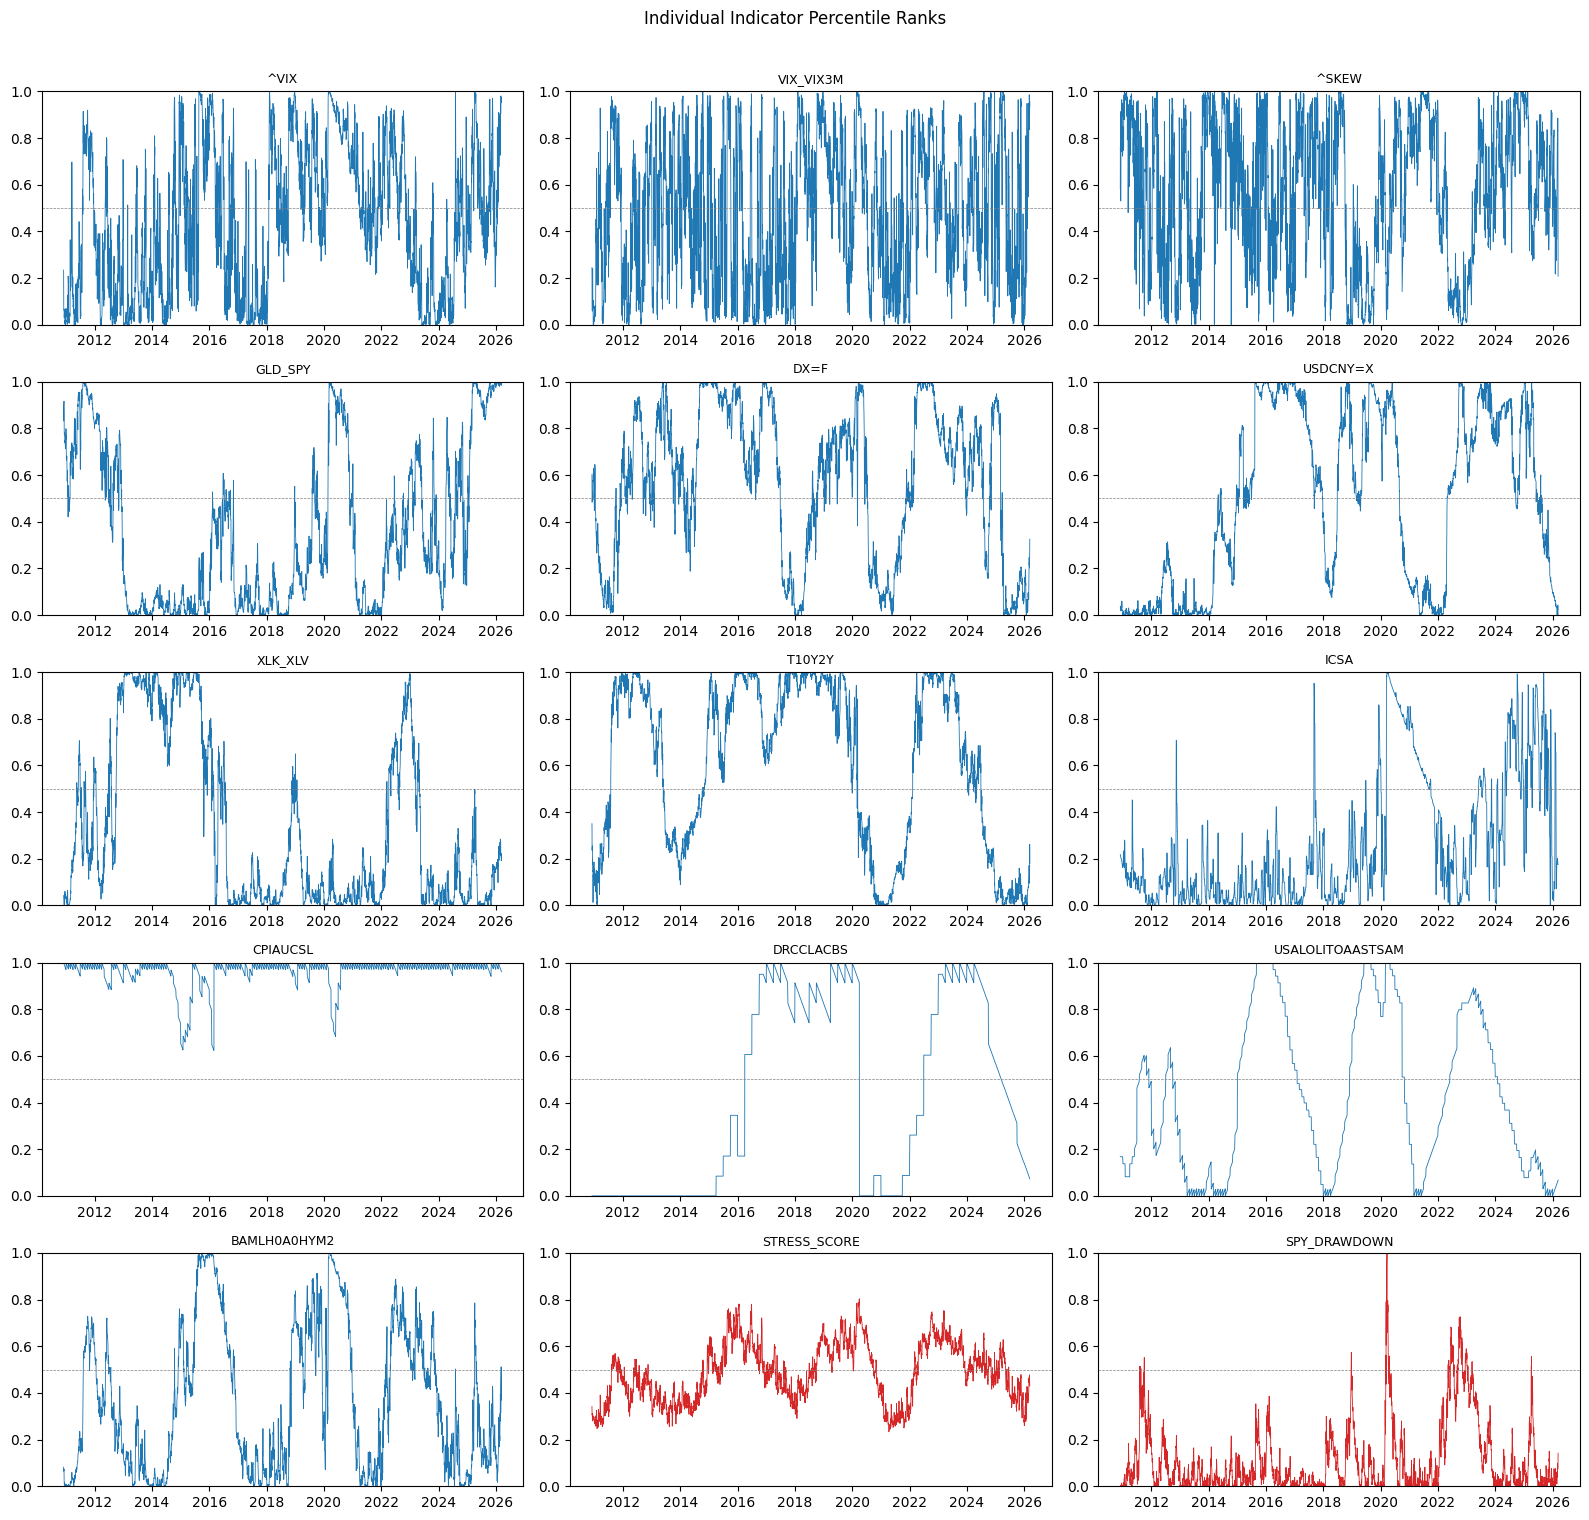

In [39]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(16, 15), sharex=False)
axes = axes.flatten()

for i, col in enumerate(score_cols):
    axes[i].plot(df.index, df[col], linewidth=0.6)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylim(0, 1)
    axes[i].axhline(0.5, color="grey", linewidth=0.5, linestyle="--")

extra = {"STRESS_SCORE": df["STRESS_SCORE"], "SPY_DRAWDOWN": spy_dd_norm}
for j, (label, series) in enumerate(extra.items()):
    axes[13 + j].plot(df.index, series, linewidth=0.6, color="#d62728")
    axes[13 + j].set_title(label, fontsize=9)
    axes[13 + j].set_ylim(0, 1)
    axes[13 + j].axhline(0.5, color="grey", linewidth=0.5, linestyle="--")

plt.suptitle("Individual Indicator Percentile Ranks", y=1.01)
plt.tight_layout()
fig.savefig(DOCS_PATH / "indicator_grid.png", bbox_inches="tight", dpi=150)
plt.show()